## Step 1: Setup Google Colab Environment (Install Necessary Libraries)

## Environment Setup Explanation

### 1. `!pip install ultralytics`
Installs the **Ultralytics YOLOv8** library.  
We use it to run an object detection model for detecting shuttlecocks.

### 2. `!pip install opencv-python-headless`
Installs **OpenCV** for image and video processing in Colab.  
We use it to read, process, and handle camera/video frames.

### 3. `!pip install matplotlib`
Installs **Matplotlib** for displaying images and results.  
We use it to show frames and detected shuttlecocks inside the notebook.

### 4. `!pip install torch torchvision torchaudio`
Installs **PyTorch** and related libraries.  
YOLOv8 runs on PyTorch, so these packages help the model work properly.

### 5. `!pip install numpy`
Installs **NumPy** for numerical and array operations.  
Images are handled as arrays, so NumPy helps in processing image data.

In [ ]:
# Install YOLOv8 and other required libraries
!pip install ultralytics  # Install the ultralytics library for YOLOv8, which includes pre-built models and utilities for object detection

# Install OpenCV to handle image processing and camera integration
!pip install opencv-python-headless  # OpenCV is used for image/video processing (using OpenCV without GUI support in Colab)

# Install matplotlib for visualization of images
!pip install matplotlib  # For plotting images and visualizing results

# Install torch (PyTorch) for running YOLO model
!pip install torch torchvision torchaudio  # PyTorch is used to run deep learning models and manage tensor computations

# Install numpy for numerical operations and array handling
!pip install numpy  # NumPy is used for matrix and array operations (essential for machine learning models)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00


## Step 2: Import Libraries in Code

After installing the necessary libraries, let’s import them into the code to be used later.

### Explanation:

- **`import cv2`**:
  - **Purpose**: Import OpenCV for image/video processing.
  - **Why**: To capture video frames and process them for shuttlecock detection.

- **`import numpy as np`**:
  - **Purpose**: Import NumPy for handling arrays.
  - **Why**: Required for image data and deep learning model processing.

- **`import torch`**:
  - **Purpose**: Import PyTorch for loading and running the YOLO model.
  - **Why**: YOLOv8 is built on PyTorch for object detection tasks.

- **`import matplotlib.pyplot as plt`**:
  - **Purpose**: Import Matplotlib for visualization.
  - **Why**: To display camera feed and detection results.

- **`from ultralytics import YOLO`**:
  - **Purpose**: Import YOLOv8 model from the ultralytics library.
  - **Why**: To use the pre-trained YOLOv8 model for shuttlecock detection.


In [ ]:
# Import required libraries

import cv2  # OpenCV for video capture and image processing
import numpy as np  # NumPy for numerical operations (array manipulations)
import torch  # PyTorch for handling deep learning models
import matplotlib.pyplot as plt  # Matplotlib for image visualization
from ultralytics import YOLO  # YOLO for object detection (pre-trained YOLO model)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Step 3: Load YOLOv8 Model

Now, let's load the YOLOv8 model. This is an essential step before performing object detection.

### Model Loading

```python
model = YOLO('yolov8n.pt')

In [ ]:
# Load the pre-trained YOLOv8 model for shuttlecock detection
model = YOLO('yolov8n.pt')  # 'yolov8n.pt' is the lightweight YOLOv8 model

##Step 4: Confirm GPU in Colab

- `import torch`: Imports the PyTorch library for tensor operations and GPU support.
- `import subprocess`: Imports the subprocess module to run system commands like `nvidia-smi`.
- `torch.cuda.is_available()`: Checks if CUDA (GPU acceleration) is available, returning `True` or `False`.
- `torch.cuda.get_device_name(0)`: Retrieves the name of the first GPU if available.
- `print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")`: Prints the GPU name if CUDA is available, else "No GPU".
- `!nvidia-smi`: Executes the `nvidia-smi` command to show GPU status, including memory usage and driver info.

In [ ]:
# Importing the torch library, which provides functionalities for tensor computation and GPU acceleration
import torch

# Importing subprocess module which allows running system commands (like !nvidia-smi) from Python
import subprocess

# Check if CUDA (NVIDIA GPU support) is available on the current machine
# torch.cuda.is_available() returns a boolean value: True if CUDA is available, False if not
print("CUDA available:", torch.cuda.is_available())

# Get the name of the GPU if CUDA is available. If not, print 'No GPU'.
# torch.cuda.get_device_name(0) fetches the name of the GPU with index 0 (first GPU).
# If CUDA is unavailable, it will print "No GPU"
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

# Run the 'nvidia-smi' system command to get detailed GPU status including memory usage, temperature, etc.
# This command is executed in the system shell through the subprocess module
# The ! operator is a shorthand for calling shell commands directly in Colab.
!nvidia-smi

CUDA available: True
GPU: Tesla T4
Wed May  6 04:51:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------

##Step 5: Mount Google Drive and upload dataset .zip in Colab.

- **Purpose**: Each comment explains the specific functionality of the code, like uploading files, creating directories, and moving files.
- **Parameters/Parts**: Comments break down the function parameters, such as `exist_ok=True` in `os.makedirs`, and explain their impact on behavior.
- **Why It's Used**: The comments clarify why each step (e.g., mounting Drive, uploading, creating directories) is needed to save files to Google Drive.

In [2]:
# Import Google Drive connector so Colab can access your personal Drive space.
from google.colab import drive  # Gives the drive.mount() function.

# Mount your Drive at '/content/drive' so files can be written permanently to MyDrive.
drive.mount('/content/drive')  # After auth, your Drive appears under this path.

Mounted at /content/drive


In [ ]:
# Import Google Drive connector so Colab can access your personal Drive space.
from google.colab import drive  # Gives the drive.mount() function.

# Mount your Drive at '/content/drive' so files can be written permanently to MyDrive.
drive.mount('/content/drive')  # After auth, your Drive appears under this path.

# Import upload helper to pick zip file from your laptop.
from google.colab import files  # files.upload() opens a local file picker.

# Upload dataset zip from your laptop to temporary Colab working directory.
uploaded = files.upload()  # Returns dict: {filename: file_bytes}.

# Get uploaded zip filename (first file).
zip_name = list(uploaded.keys())[0]  # Assumes one uploaded zip.

# Import os/shutil for folder creation and moving file.
import os  # For path and directory utilities.
import shutil  # For moving files between locations.

# Define permanent folder path inside your Google Drive.
save_dir = '/content/drive/MyDrive/ShuttleBot/datasets'  # MyDrive is persistent storage.

# Create the folder if it doesn't already exist.
os.makedirs(save_dir, exist_ok=True)  # No error if folder already exists.

# Build full final path for the zip in Drive.
final_zip_path = os.path.join(save_dir, zip_name)  # Safe path join.

# Move uploaded zip from temporary Colab storage to permanent Drive storage.
shutil.move(zip_name, final_zip_path)  # Now zip is saved permanently in Drive.

# Print saved location for confirmation.
print('Saved permanently at:', final_zip_path)

##Step 6: ZIP Extraction

- `import zipfile`: Imports Python’s built-in ZIP tool to open and extract `.zip` files.
- `import os`: Helps create folders and handle file paths safely.
- `zip_path`: Stores the full location of the ZIP file in Google Drive.
- `extract_dir`: Stores the folder path where the dataset will be extracted permanently.
- `os.makedirs(..., exist_ok=True)`: Creates the extraction folder if it does not exist; avoids error if it already exists.
- `ZipFile(zip_path, 'r')`: Opens the ZIP file in read-only mode.
- `extractall(path=extract_dir)`: Extracts all files and folders from the ZIP into the selected folder.
- `print(...) / os.listdir(...)`: Confirms extraction and shows extracted folder/file names.

In [3]:
# Import the zipfile module so we can read .zip archives and extract files from them.
import zipfile  # 'zipfile' is Python's standard library for ZIP handling (no pip install needed).

# Import os so we can join paths, create folders, and list directory contents safely.
import os  # 'os' provides operating-system style path operations like os.path.join and os.makedirs.

# Define the full path to your dataset zip file on Google Drive after mounting Drive in Colab.
# - '/content/drive' is where Colab mounts Google Drive.
# - 'MyDrive' is your personal Drive root.
# - 'ShuttleBot/datasets/DataSet.zip' must match your actual folder + filename (case-sensitive on Linux VM).
zip_path = '/content/drive/MyDrive/ShuttleBot/datasets/DataSet.zip'  # This string is the exact location of the uploaded zip.

# Define the folder where the zip contents will be extracted and stored permanently on Drive.
# - Same Drive root as above; 'DataSet_extracted' is a new folder name for unpacked data (you can rename if you want).
extract_dir = '/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted'  # All extracted files will live under this directory.

# Create extract_dir (and any missing parent folders) if it does not exist yet.
# - extract_dir is the path we want to create.
# - exist_ok=True means: do not raise an error if the folder already exists (safe to re-run the cell).
os.makedirs(extract_dir, exist_ok=True)  # Ensures extraction target exists before writing files.

# Open the zip file in read mode and extract everything into extract_dir.
# - zip_path: which archive to open.
# - 'r': read mode (required for extraction; we are not modifying the zip).
# - with ... as z: automatically closes the zip file after the block (good practice, avoids file locks).
# - z.extractall(path=extract_dir): unpacks all files/folders from the zip into extract_dir.
with zipfile.ZipFile(zip_path, 'r') as z:  # 'z' is the opened ZipFile object bound to zip_path in read mode 'r'.
    z.extractall(path=extract_dir)  # Extract every member of the archive into the folder extract_dir.

# Print a clear message showing where extraction finished (helps you copy the path for the next step).
print('Extraction complete. Files are in:', extract_dir)  # str concatenation via comma in print shows the final folder path.

# List the first-level names inside extract_dir so you can see folders like train/images, or YOLO layout, etc.
# - os.listdir(extract_dir): returns a list of entry names (files and subfolders) directly under extract_dir.
# - [:20]: slice limits output to first 20 items so the notebook does not flood if there are many files.
print('Top-level contents (first 20):', os.listdir(extract_dir)[:20])  # Quick visual verification that unzip produced expected structure.

Extraction complete. Files are in: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted
Top-level contents (first 20): ['merged_dataset']


##Step 7: Inspect merged_dataset and Create data.yaml
- **base_dir**: Root folder of the dataset in Drive; used for relative paths in `data.yaml`.
- **os.walk / listing**: List subfolders to handle different folder names (e.g., `train/images`, `valid/images`).
- **Path (pathlib)**: Ensures clean path joining and existence checks, preventing errors.
- **data.yaml**: Defines YOLO class count, names, and image paths for training/validation.
- **Absolute paths in YAML**: Ensures paths work reliably in Colab after Drive mount.

In [4]:
# Import os so we can list directories and check whether paths exist on the filesystem.
import os  # 'os' module: functions like os.path.isdir, os.listdir, os.walk for filesystem inspection.

# Import Path from pathlib for object-oriented paths (join with /, check .exists(), iterate .iterdir()).
from pathlib import Path  # 'Path' is a class representing filesystem paths in a cross-platform way.

# Import yaml writer: PyYAML is used to dump a Python dictionary into a valid YAML file for Ultralytics.
# If this import fails in your notebook, run once: !pip install pyyaml
import yaml  # 'yaml' module: yaml.safe_dump writes human-readable YAML; safe_load reads it (we only dump here).

# Define the root folder where your extracted dataset lives (must match your actual unzip location).
# - Path(...) wraps the string so we can use path operations like .exists() and / for joining.
base_dir = Path('/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset')  # This is the 'merged_dataset' folder you saw in the top-level listing.

# Verify base_dir exists; if not, print a clear error so you know the path string is wrong (typo or different unzip name).
if not base_dir.exists():  # .exists() returns True if this path is a file or directory on disk.
    raise FileNotFoundError(f'Missing folder: {base_dir}')  # f-string inserts base_dir into message; raises to stop early.

# Print the absolute resolved path (helps confirm Colab sees the same Drive path you expect).
print('Dataset root:', base_dir.resolve())  # .resolve() follows symlinks and shows canonical absolute path.

# List immediate children of base_dir (first level only) to see names like train, valid, test, data.yaml, etc.
print('Inside merged_dataset:', [p.name for p in base_dir.iterdir()])  # iterdir() yields Path objects; p.name is folder/file name; list comprehension builds a simple list.

# Helper function: return Path to subdirectory if it exists, else None (avoids repeating if/else blocks).
def pick_existing(subpath):  # subpath: string like 'train/images' relative to base_dir.
    p = base_dir / subpath  # / operator joins Path base_dir with relative subpath parts.
    return p if p.exists() else None  # conditional expression: return Path if exists, else None.

# Try common Ultralytics / Roboflow folder names for training images (Roboflow export often uses train/images).
train_img_dir = pick_existing('train/images')  # First candidate: train/images under base_dir.

# If train/images not found, try alternate name train/Images (some zips use capital I).
if train_img_dir is None:  # Only try fallback when first pick did not exist.
    train_img_dir = pick_existing('train/Images')  # Capital I variant for images folder.

# Try validation images folder named valid/images (common in Roboflow YOLO v5/v8 exports).
val_img_dir = pick_existing('valid/images')  # valid/images is typical Roboflow naming.

# If valid/images missing, try val/images (some datasets use val instead of valid).
if val_img_dir is None:  # Fallback chain for validation image directory.
    val_img_dir = pick_existing('val/images')  # val/images alternate naming.

# If still missing, try valid/Images with capital I (case sensitivity on Linux Colab VM).
if val_img_dir is None:  # Another fallback for capitalization differences.
    val_img_dir = pick_existing('valid/Images')  # Capital I variant under valid.

# If still missing, try val/Images capital I.
if val_img_dir is None:  # Last common capitalization fallback for val split.
    val_img_dir = pick_existing('val/Images')  # Capital I under val.

# If training images folder still not found, try flat layout: images/ at base (some merges put all in one folder).
if train_img_dir is None:  # When no train/images style structure detected.
    train_img_dir = pick_existing('images')  # Single images folder at root of merged_dataset.

# For validation, if no valid/val split exists, set val_img_dir to None (we may use same folder or split later).
# (No assignment here; val_img_dir may already be None.)

# Print which image folders were detected so you can visually confirm before training.
print('train_img_dir =', train_img_dir)  # Shows resolved Path or None if not found.
print('val_img_dir   =', val_img_dir)  # Shows resolved Path or None if not found.

# Safety check: training images directory must exist or YOLO cannot train.
if train_img_dir is None:  # None means none of the candidate relative paths existed.
    raise FileNotFoundError('Could not find training images folder. Expected train/images or images/. Inspect folder structure.')  # Stops execution with helpful hint.

# Count a few image files in train folder to confirm non-empty (extensions list covers common formats).
img_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}  # set of lowercase extensions; set membership tests are fast.
train_imgs = [f for f in train_img_dir.iterdir() if f.is_file() and f.suffix.lower() in img_exts]  # iterdir loops entries; is_file skips dirs; suffix.lower() normalizes .JPG to .jpg; in img_exts filters images.
print('Training images found (count):', len(train_imgs))  # len counts list length; quick sanity check.

# If validation folder missing, Ultralytics can still train but you should add val for proper metrics; warn only.
if val_img_dir is None:  # Missing validation split reduces reliable mAP reporting during training.
    print('WARNING: No validation images folder found (valid/images or val/images). You can add split later or use train also as val temporarily.')  # Inform user; not fatal for some quick tests.

# Optional: try to detect number of classes and names from data.yaml if author included it inside dataset.
existing_yaml = base_dir / 'data.yaml'  # Roboflow sometimes ships data.yaml at dataset root.
names = ['shuttlecock']  # default single-class name list (Python list of strings).
nc = 1  # nc means number of classes; default 1 for shuttlecock-only dataset.

# If packaged data.yaml exists, read names/nc from it to avoid mismatch with label indices.
if existing_yaml.exists():  # Only parse if file is present.
    with existing_yaml.open('r', encoding='utf-8') as f:  # open text file for reading; utf-8 avoids encoding issues.
        meta = yaml.safe_load(f)  # safe_load parses YAML into Python dict/list structures safely.
    # If meta is dict and contains 'names', reuse it (could be dict id->name or list).
    if isinstance(meta, dict) and 'names' in meta:  # isinstance checks meta is a dictionary; 'names' key holds class names.
        names_field = meta['names']  # pull names field from yaml dict.
        # If names_field is dict like {0: 'shuttlecock'}, convert to ordered list by sorted keys.
        if isinstance(names_field, dict):  # Roboflow YAML often uses mapping from class id to name.
            names = [names_field[k] for k in sorted(names_field.keys(), key=lambda x: int(x))]  # sorted keys as ints; list preserves class order 0..nc-1.
        else:
            names = list(names_field)  # if already a list, copy to list() for a concrete list.
        nc = int(meta.get('nc', len(names)))  # meta.get('nc', default) reads nc if present else len(names); int() ensures integer type.

# Build Ultralytics dataset dict: path is dataset root; train/val are paths to image folders (strings).
data = {  # Python dict will become YAML mapping.
    'path': str(base_dir.resolve()),  # 'path': optional but useful; absolute root of dataset on Drive.
    'train': str(train_img_dir.resolve()),  # 'train': required; folder containing training images.
    'val': str(val_img_dir.resolve()) if val_img_dir is not None else str(train_img_dir.resolve()),  # 'val': required by Ultralytics; fallback to train if val missing (not ideal but lets pipeline run).
    'names': names,  # 'names': class name list indexed by label id in label files.
    'nc': nc,  # 'nc': number of classes; should match length of names for consistency.
}

# Define output path for the new yaml we write (separate name avoids overwriting original if you want to keep it).
out_yaml = base_dir / 'data_colab.yaml'  # Saving beside dataset keeps everything in one project folder on Drive.

# Write data dict to YAML file with default_flow_style=False for multi-line readable YAML.
with out_yaml.open('w', encoding='utf-8') as f:  # open for write; utf-8 encoding for text.
    yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)  # sort_keys=False preserves train/val order; allow_unicode=True keeps non-ASCII names if any.

# Print where yaml was saved so you can copy path into training command in the next step.
print('Wrote:', out_yaml.resolve())  # Shows final absolute path of created yaml file.

# Print yaml content to notebook output for quick manual verification.
print('\n--- data_colab.yaml ---')  # Blank line header for readability in output.
print(out_yaml.read_text(encoding='utf-8'))  # read_text loads entire file as string for display.

Dataset root: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset
Inside merged_dataset: ['data.yaml', 'test', 'train', 'valid']
train_img_dir = /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/train/images
val_img_dir   = /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/valid/images
Training images found (count): 10816
Wrote: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/data_colab.yaml

--- data_colab.yaml ---
path: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset
train: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/train/images
val: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/valid/images
names:
- shuttle
nc: 1



##Step 8: Install Ultralytics and Train YOLO on the Dataset
- `!pip install ultralytics`: Installs the YOLOv8 package. Needed for training, validation, and exporting YOLO models.
- `from ultralytics import YOLO`: Imports the high-level YOLO API to manage model operations (load, train, validate).
- `YOLO('yolov8n.pt')`: Loads pretrained nano weights (fast, small). Use `yolov8s.pt` for higher accuracy.
- `model.train(...)`: Fine-tunes the model on your dataset. Controls parameters like epochs, image size, and batch size.
- `data_yaml path`: Points to your YAML file (e.g., `data_colab.yaml`). Contains train/val data info.
- `!pip install -q ultralytics`: Installs the YOLOv8 package quietly in Colab, ensuring it's available for imports.
  

In [5]:
# Import the YOLO class from the ultralytics package so we can construct a model object and call .train().
from ultralytics import YOLO  # 'ultralytics' is the installed library; 'YOLO' is the main model wrapper class.

# Define the absolute path string to your dataset YAML file created in Step 7 (must exist on mounted Google Drive).
# - This string tells Ultralytics where train/val image folders and class names are defined.
# - Using the same path you printed as "Wrote: ... data_colab.yaml" avoids typos.
data_yaml = '/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/data_colab.yaml'  # Python str holding filesystem path.

# Construct a YOLO model object starting from pretrained checkpoint file 'yolov8n.pt'.
# - 'yolov8n.pt' means YOLOv8 *nano*: smallest/fastest variant; good baseline on a T4 GPU.
# - The .pt file will download automatically the first time if not cached.
# Purpose: transfer learning — reuse general object detection features, then fine-tune on shuttle.
# Why: training from random weights would need more time/data; pretrained weights converge faster.
model = YOLO('yolov8n.pt')  # model is now an object with methods like .train(), .val(), .predict().

# Start training (fine-tuning) using keyword arguments for clarity.
# - data=data_yaml: path to YAML containing keys like train, val, names, nc.
# - epochs=50: number of full passes over the training set (increase for better accuracy, longer runtime).
# - imgsz=640: resize/pad images so the longest side training size is 640 pixels (standard for YOLOv8).
# - batch=16: number of images processed together per optimizer step (lower if CUDA out-of-memory).
# - device=0: use first CUDA GPU in the VM (your T4); use 'cpu' only if GPU unavailable.
# - workers=2: number of DataLoader worker processes for loading images (Colab is stable with small values).
# - project='/content/drive/MyDrive/ShuttleBot/runs': folder root on Drive to store run outputs persistently.
# - name='shuttle_train_v1': subfolder name for this experiment under project/.
# - exist_ok=True: allow reusing the same name folder without error (overwrite behavior controlled by Ultralytics).
# Purpose: produce trained weights (best.pt) and metrics plots under the run directory.
results = model.train(  # .train returns a Results object; assigning to 'results' keeps reference for optional inspection.
    data=data_yaml,  # dataset definition file path (string).
    epochs=50,  # training epochs (int); more epochs can improve mAP until overfitting.
    imgsz=640,  # image size (int) used during training.
    batch=16,  # batch size (int); reduce to 8 if you see torch.cuda.OutOfMemoryError.
    device=0,  # GPU index 0 (int) selects Tesla T4 in Colab when CUDA is available.
    workers=2,  # dataloader workers (int); too high can cause Colab instability.
    project='/content/drive/MyDrive/ShuttleBot/runs',  # persistent output root on Google Drive.
    name='shuttle_train_v1',  # experiment/run name used in folder naming.
    exist_ok=True,  # boolean; True means training may continue into same run naming scheme without crashing on duplicate.
)  # end of model.train(...) call.

# Print a helpful message pointing to where Ultralytics typically saves the best weights.
# - After training, look for: project/name/weights/best.pt
print('Training finished. Check weights in: /content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/weights/')  # informational string for your report/notebook.

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/data_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=shuttle_train_v1, nbs=64, nms=False, opset=N

## Step 9: Create a clean permanent model folder
Copy best.pt there with a clear name (for report/simulation use).

In [6]:
# Import the 'os' module to interact with the operating system for file and directory operations.
import os

# Import the 'shutil' module to perform high-level file operations like copying files.
import shutil

# Define the source file path for the pretrained model (best.pt) in your Drive.
src = '/content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/weights/best.pt'
# 'src' points to the current location of the model file you want to copy.

# Define the destination directory where you want to store the model (if it doesn't exist).
dst_dir = '/content/drive/MyDrive/ShuttleBot/models'
# 'dst_dir' is where the model will be saved. It's a folder inside 'MyDrive'.

# Define the full destination path, including the new filename for the model.
dst = '/content/drive/MyDrive/ShuttleBot/models/shuttle_yolov8n_best.pt'
# 'dst' is the full path where the model will be copied to, with a new name.

# Create the destination directory if it doesn't exist yet. 'exist_ok=True' ensures no error if the folder already exists.
os.makedirs(dst_dir, exist_ok=True)
# This ensures the 'models' directory exists before copying the file. It won’t raise an error if the directory is already there.

# Copy the model file from the source to the destination, preserving metadata like timestamps.
shutil.copy2(src, dst)
# 'shutil.copy2' copies the model from 'src' to 'dst' and retains file metadata (like modification date).

# Print the path where the model was saved to confirm the action.
print('Saved model at:', dst)
# This prints the final location of the saved model to confirm the operation was successful.

Saved model at: /content/drive/MyDrive/ShuttleBot/models/shuttle_yolov8n_best.pt


## Step 10: Run Inference on Test Images and Save Prediction Results
- **Load model from Drive**: Load your final trained `best.pt` for reporting and simulation.
- **Point to test image folder**: Use unseen data (`test/images`) to evaluate generalization performance.
- **Set confidence threshold**: Filter weak detections to reduce false positives in visuals.
- **Save predictions to Drive**: Save outputs permanently in Drive for assignment evidence (Colab is temporary).

In [ ]:
# Import YOLO class from ultralytics so we can load trained weights and run prediction.
from ultralytics import YOLO  # YOLO is the main API class for detect/train/val/predict tasks.

# Import os for checking/creating folders and building file paths safely.
import os  # os.path functions and os.makedirs are used for filesystem operations.

# Path to your permanently saved trained model file on Google Drive.
# - '/content/drive/MyDrive/...' is the mounted Drive path in Colab.
# - 'shuttle_yolov8n_best.pt' is the best checkpoint copied in previous step.
model_path = '/content/drive/MyDrive/ShuttleBot/models/shuttle_yolov8n_best.pt'  # Model weights path string.

# Path to test images folder from your extracted dataset structure.
# - This must contain image files (.jpg/.png/etc.) only (or mostly).
test_images_dir = '/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/test/images'  # Source images for inference.

# Output root folder on Drive where prediction images and logs will be saved permanently.
# - We keep outputs inside ShuttleBot/runs for organization.
output_project_dir = '/content/drive/MyDrive/ShuttleBot/runs'  # Persistent project directory for predict results.

# Name of this prediction run folder (will create: output_project_dir/name).
# - Change this name if you want separate runs (e.g., 'predict_test_v2').
output_run_name = 'predict_test_v1'  # Folder tag for this inference run.

# Create output root folder if it does not already exist.
# - exist_ok=True prevents error when folder already exists.
os.makedirs(output_project_dir, exist_ok=True)  # Ensure save destination exists.

# Load the trained YOLO model from model_path.
# - YOLO(...) constructs a model object ready for inference.
model = YOLO(model_path)  # Load your custom-trained shuttle detector.

# Run prediction on all images in test_images_dir.
# - source=test_images_dir: input source folder containing test images.
# - conf=0.25: confidence threshold; detections below 0.25 are discarded.
# - imgsz=640: inference image size (same scale family used during training).
# - save=True: save visualized prediction images (with boxes/labels) to disk.
# - project=output_project_dir: root directory where run folder is created.
# - name=output_run_name: specific run folder name under project.
# - exist_ok=True: allow writing into existing run folder name without crashing.
# - device=0: use GPU index 0 (Tesla T4) for faster inference.
results = model.predict(
    source=test_images_dir,
    conf=0.25,
    imgsz=640,
    save=True,
    project=output_project_dir,
    name=output_run_name,
    exist_ok=True,
    device=0
)  # 'results' contains prediction objects for each processed image.

# Build final output path string where predicted images are saved.
saved_predictions_path = os.path.join(output_project_dir, output_run_name)  # Combines root + run folder name.

# Print final location so you can open it directly in Drive and use images in your report.
print('Predictions saved at:', saved_predictions_path)  # Confirmation message.


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1509 /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/test/images/1_video_label_1_1002_jpg.rf.b2713e597ec6ce89abcb82781acc451a.jpg: 384x640 1 shuttle, 44.3ms
image 2/1509 /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/test/images/1_video_label_1_1013_jpg.rf.a6643e4ee8b0bafdeeb79cda95a4c80e.jpg: 384x640 (no detections), 7.0ms
image 3/1509 /content/drive/MyDrive/ShuttleBot/datasets/DataSet_ext

## Step 11: Evaluate Model on Test Set and Save Final Metrics
- **Why**: Prediction images provide visual proof, but numeric performance is also needed for the report.
- **What it does**: Validates on `test/images` and `test/labels` using the trained `best.pt`.
- **What you get**: Final metrics printed and saved in a folder on Google Drive.

In [8]:
# Import YAML and path tools.
import yaml
from pathlib import Path

# Point to your existing YAML file.
yaml_path = Path('/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/data_colab.yaml')

# Read current YAML content.
data = yaml.safe_load(yaml_path.read_text())

# Add test images path (this is the missing key causing the error).
data['test'] = '/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/test/images'

# Save updated YAML back to disk.
yaml_path.write_text(yaml.safe_dump(data, sort_keys=False), encoding='utf-8')

# Print final YAML so you can verify train/val/test all exist.
print(yaml_path.read_text())

path: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset
train: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/train/images
val: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/valid/images
names:
- shuttle
nc: 1
test: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/test/images



In [9]:
# Call the validation function of the model and evaluate its performance on a test dataset
metrics = model.val(
    # Specifies the path to the YAML configuration file that contains details about the dataset (location, class labels, etc.)
    data='/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/data_colab.yaml',

    # Sets the split of the dataset to use. 'test' means using the test subset of the dataset for evaluation
    split='test',

    # Sets the image size to which input images will be resized for evaluation. 640 pixels is a common choice for many models
    imgsz=640,

    # Specifies the batch size, i.e., how many images will be processed simultaneously during evaluation. Here, it's 4 images per batch
    batch=4,

    # Sets the device on which the model will run. 'cpu' specifies to run the model on the CPU (no GPU usage)
    device='cpu',

    # Defines the number of worker threads to use for data loading. Here it's set to 1, meaning 1 thread will handle data loading
    workers=1,

    # Specifies the directory to save the results (logs, model checkpoints, etc.). Here it's set to a folder in Google Drive
    project='/content/drive/MyDrive/ShuttleBot/runs',

    # Defines the name of the run, so the results of this validation are saved with this specific name
    name='val_test_cpu_v3',

    # If a folder with the same name already exists, this parameter ensures it will be overwritten without raising an error
    exist_ok=True
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 1.0±0.3 ms, read: 0.7±0.1 MB/s, size: 192.6 KB)
val: Scanning /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/test/labels... 1509 images, 53 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1509/1509 3.4it/s 7:25
val: New cache created: /content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 378/378 1.3it/s 4:58
                   all       1509       1493      0.829      0.624      0.708      0.358
Speed: 3.6ms preprocess, 173.3ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/drive/MyDrive/ShuttleBot/runs/val_test_cpu_v3


##Step 12: Set Up Colab Environment for Plots/Visualizations


In [10]:
# Import 'drive' helper from Google Colab so this notebook can access files saved in your Google Drive.
from google.colab import drive  # 'google.colab' is Colab's built-in package; 'drive' module provides mount().

# Mount Google Drive into the Colab filesystem at '/content/drive'.
# - '/content/drive' is the mount location inside Colab VM.
# - force_remount=True forces a fresh reconnect to avoid stale/disconnected mounts.
drive.mount('/content/drive', force_remount=True)  # Purpose: make your dataset/model/runs available in this session.

# Install Ultralytics package quietly.
# - Leading '!' means run as shell command (not Python).
# - 'pip install' installs Python packages in current runtime.
# - '-q' reduces noisy output in notebook.
# - 'ultralytics' is needed to read YOLO training artifacts and utility plots.
!pip install -q ultralytics  # Purpose: ensure YOLO-related tools are available after runtime reset.

# Install plotting and data-analysis libraries quietly.
# - matplotlib: main plotting library for charts/figures.
# - seaborn: nicer statistical plotting style and quick distribution plots.
# - pandas: load and analyze CSV files like YOLO results.csv.
# - pyyaml: read YAML config files (dataset/model configs).
!pip install -q matplotlib seaborn pandas pyyaml  # Purpose: core stack for metrics graphs and dataset visualizations.

# Import 'os' for path checks and directory/file existence validation.
import os  # Used for os.path.exists(), path handling, and environment checks.

# Import 'glob' to quickly list files matching patterns (e.g., *.csv, *.jpg).
import glob  # Helps find run artifacts such as results.csv and confusion matrix images.

# Import 'yaml' to read dataset YAML files (train/val/test paths and class names).
import yaml  # Used to parse data_colab.yaml safely.

# Import NumPy for numerical operations used in plotting computations.
import numpy as np  # Helpful for arrays, statistics, and basic numeric transforms.

# Import pandas for reading tabular experiment logs like YOLO results.csv.
import pandas as pd  # DataFrame operations for plotting metric trends by epoch.

# Import matplotlib's pyplot API with common alias 'plt'.
import matplotlib.pyplot as plt  # Used to build line plots, bar charts, histograms, etc.

# Import seaborn for higher-level statistical visualizations with good default styling.
import seaborn as sns  # Useful for distributions and cleaner project-ready plots.

# Apply seaborn theme for cleaner, report-friendly chart appearance.
# - style='whitegrid' adds readable grid lines.
# - context='notebook' sets balanced font/element sizes for notebook outputs.
sns.set_theme(style='whitegrid', context='notebook')  # Purpose: consistent styling for all upcoming figures.

# Define path to your trained run folder that contains YOLO outputs (results.csv, plots, weights).
run_dir = '/content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1'  # Change only if your run folder name is different.

# Define path to your dataset YAML file used during training.
data_yaml_path = '/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset/data_colab.yaml'  # Used to confirm dataset metadata.

# Check and print whether run directory exists.
print('Run directory exists:', os.path.exists(run_dir))  # True means training artifacts are accessible.

# Check and print whether dataset YAML exists.
print('Dataset YAML exists:', os.path.exists(data_yaml_path))  # True means data config is ready for later visual steps.

# Find CSV files in run folder (results.csv is the most important for metric-vs-epoch plots).
csv_files = glob.glob(os.path.join(run_dir, '*.csv'))  # Pattern: all .csv files directly inside run_dir.

# Print discovered CSV files so you can verify results.csv is available.
print('CSV files found:', csv_files)  # Expected to include something like .../results.csv

# Find common YOLO-generated plot images in the run folder.
plot_images = glob.glob(os.path.join(run_dir, '*.png')) + glob.glob(os.path.join(run_dir, '*.jpg'))  # Collect PNG and JPG artifacts.

# Print count of plot images to confirm training visuals were saved.
print('Plot images found:', len(plot_images))  # Non-zero means we can reuse existing visuals in report.

Mounted at /content/drive
Run directory exists: True
Dataset YAML exists: True
CSV files found: ['/content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/results.csv']
Plot images found: 20


##Step 13: Plot Training Curves (Most Important Graph)


Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


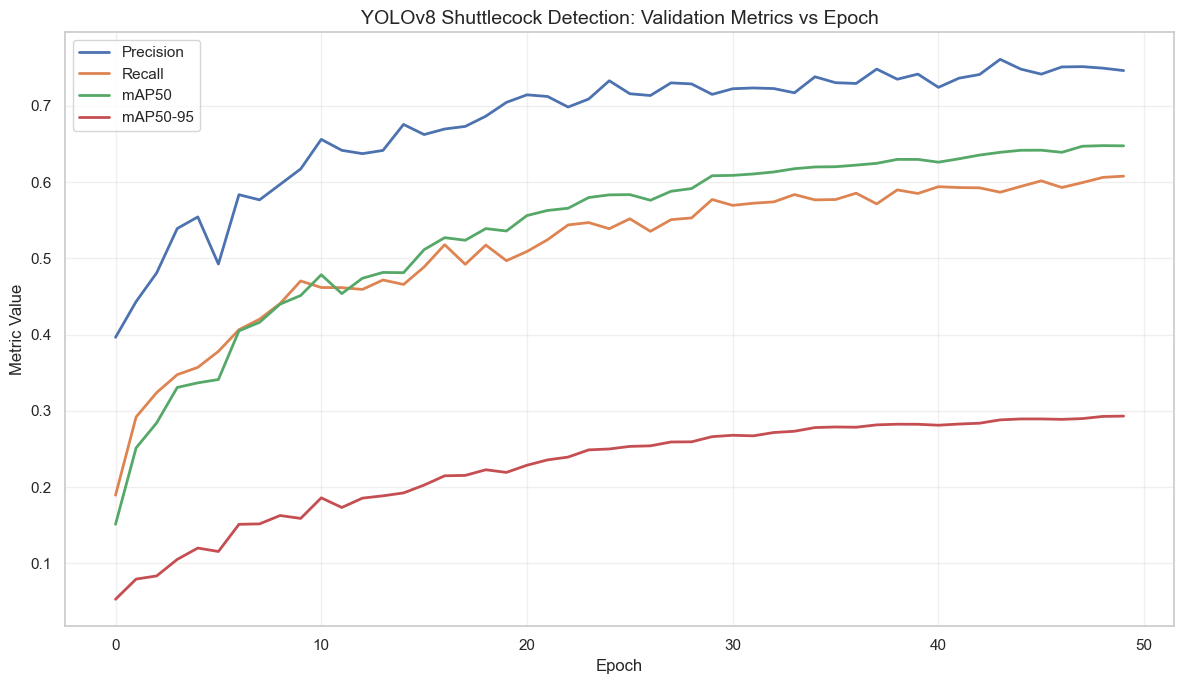

Saved plot at: /content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/plot_metrics_vs_epoch.png


In [11]:
# Import pandas to read YOLO's results.csv file into a table (DataFrame).
import pandas as pd  # Purpose: easy CSV loading and column-based plotting.

# Import matplotlib plotting API to create line charts.
import matplotlib.pyplot as plt  # Purpose: build and customize the training curves figure.

# Define exact path to results.csv generated by your training run.
# - This file stores per-epoch metrics like precision, recall, mAP, and losses.
results_csv_path = '/content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/results.csv'  # Change only if run folder changes.

# Read the CSV file into a DataFrame.
# - pd.read_csv(path) loads tabular data where each row corresponds to one epoch.
df = pd.read_csv(results_csv_path)  # 'df' now contains all epoch-wise training/validation metrics.

# Print DataFrame column names so we can verify exact metric column names in your file.
# - YOLO version differences can slightly change names, so this check prevents plotting errors.
print('Available columns:', df.columns.tolist())  # tolist() converts Index object to normal Python list for readable output.

# Create a new figure with custom size for clearer report-quality visibility.
# - figsize=(12, 7): 12 inches width, 7 inches height.
plt.figure(figsize=(12, 7))  # Larger canvas makes multiple curves readable.

# Plot validation Precision vs epoch.
# - df.index gives epoch row index (0-based in CSV).
# - 'metrics/precision(B)' is YOLO detection precision metric column.
# - label sets legend name shown in plot.
# - linewidth controls line thickness for visibility.
plt.plot(df.index, df['metrics/precision(B)'], label='Precision', linewidth=2)  # Higher precision means fewer false positives.

# Plot validation Recall vs epoch.
# - 'metrics/recall(B)' tracks how many true objects are detected.
plt.plot(df.index, df['metrics/recall(B)'], label='Recall', linewidth=2)  # Higher recall means fewer missed shuttles.

# Plot mAP@0.50 vs epoch.
# - 'metrics/mAP50(B)' is mAP at IoU 0.50 threshold.
plt.plot(df.index, df['metrics/mAP50(B)'], label='mAP50', linewidth=2)  # Common benchmark metric for object detection.

# Plot mAP@0.50:0.95 vs epoch.
# - 'metrics/mAP50-95(B)' is stricter and more informative modern metric.
plt.plot(df.index, df['metrics/mAP50-95(B)'], label='mAP50-95', linewidth=2)  # Main overall quality indicator.

# Set x-axis label text.
plt.xlabel('Epoch', fontsize=12)  # X-axis represents training progression over epochs.

# Set y-axis label text.
plt.ylabel('Metric Value', fontsize=12)  # Y-axis shows metric values between 0 and 1 usually.

# Set chart title for report context.
plt.title('YOLOv8 Shuttlecock Detection: Validation Metrics vs Epoch', fontsize=14)  # Explains exactly what graph shows.

# Display legend so each colored line is identifiable.
plt.legend(fontsize=11)  # Improves readability of multiple curves.

# Enable grid to make value reading easier from the chart.
plt.grid(True, alpha=0.3)  # alpha controls grid transparency (lighter grid = cleaner look).

# Adjust layout to prevent label/title clipping.
plt.tight_layout()  # Automatically optimizes spacing around plot elements.

# Save figure permanently to Google Drive in your run folder.
# - dpi=300 gives high-resolution export for assignment report.
# - bbox_inches='tight' trims extra blank borders around figure.
save_path = '/content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/plot_metrics_vs_epoch.png'  # Output image path.
plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Persist high-quality figure for report insertion.

# Show the plot in notebook output.
plt.show()  # Renders figure inline so you can visually verify it.

# Print saved file path confirmation.
print('Saved plot at:', save_path)  # Quick confirmation for locating the exported figure.

## Step 14: Plot Training vs Validation Loss Curves

Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


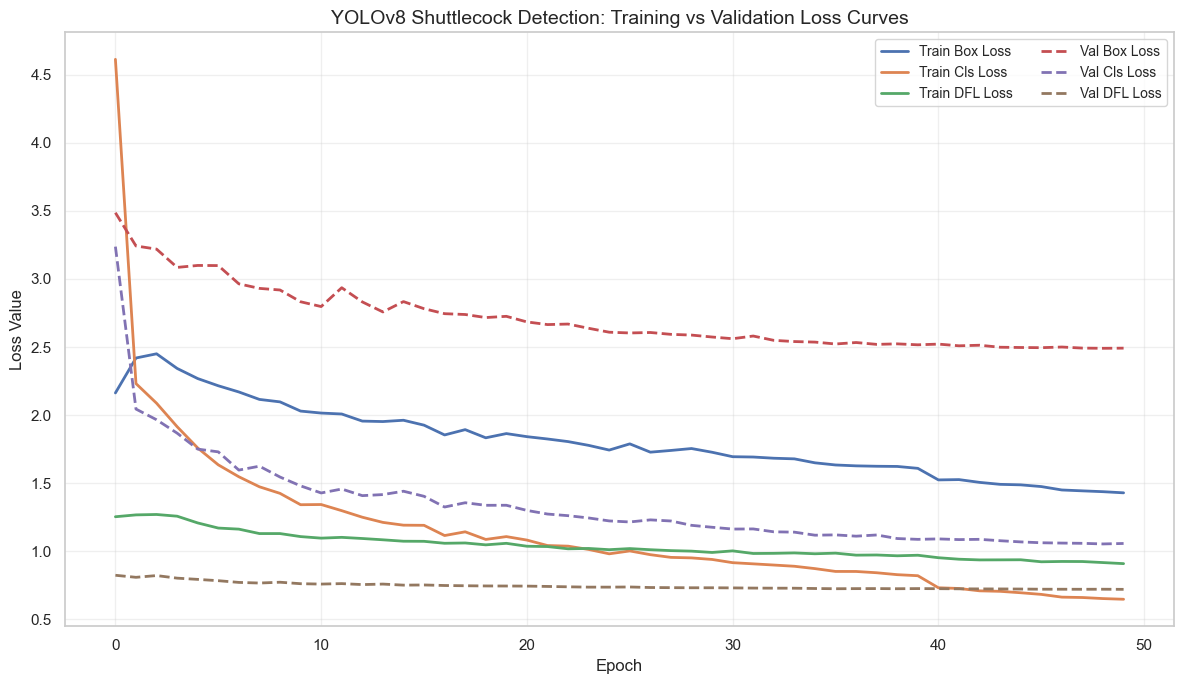

Saved plot at: /content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/plot_loss_curves_train_vs_val.png


In [12]:
# Import pandas to read the epoch-wise training log CSV into a DataFrame table.
import pandas as pd  # Purpose: structured access to columns like train/val losses.

# Import matplotlib for creating and saving line charts.
import matplotlib.pyplot as plt  # Purpose: plot loss curves clearly for report evidence.

# Set the path to YOLO training results file that stores per-epoch metrics and losses.
results_csv_path = '/content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/results.csv'  # Must point to the run you trained.

# Load CSV into DataFrame so each metric/loss column can be plotted by epoch.
df = pd.read_csv(results_csv_path)  # df rows = epochs; df columns = recorded metrics/losses.

# Print column names to confirm exact loss column names available in your YOLO version.
print('Available columns:', df.columns.tolist())  # Useful safety check before plotting.

# Create a figure with larger size so all loss lines remain readable in one chart.
plt.figure(figsize=(12, 7))  # figsize tuple is (width_inches, height_inches).

# Plot training box loss across epochs.
# - df.index is epoch sequence from CSV row order.
# - 'train/box_loss' is bounding-box regression loss on training data.
# - label is used in legend.
# - linewidth controls thickness for visual clarity.
plt.plot(df.index, df['train/box_loss'], label='Train Box Loss', linewidth=2)  # Lower trend is expected as model learns localization.

# Plot training classification loss across epochs.
# - 'train/cls_loss' is class prediction loss on training data.
plt.plot(df.index, df['train/cls_loss'], label='Train Cls Loss', linewidth=2)  # Lower values indicate better class confidence learning.

# Plot training DFL loss across epochs.
# - 'train/dfl_loss' is Distribution Focal Loss used by YOLO for box quality.
plt.plot(df.index, df['train/dfl_loss'], label='Train DFL Loss', linewidth=2)  # Lower trend indicates improved box distribution learning.

# Plot validation box loss across epochs.
# - 'val/box_loss' measures box error on unseen validation images.
plt.plot(df.index, df['val/box_loss'], label='Val Box Loss', linewidth=2, linestyle='--')  # Dashed style distinguishes validation from training.

# Plot validation classification loss across epochs.
# - 'val/cls_loss' measures class prediction error on validation set.
plt.plot(df.index, df['val/cls_loss'], label='Val Cls Loss', linewidth=2, linestyle='--')  # Compare with train cls loss for overfitting signs.

# Plot validation DFL loss across epochs.
# - 'val/dfl_loss' is validation DFL component.
plt.plot(df.index, df['val/dfl_loss'], label='Val DFL Loss', linewidth=2, linestyle='--')  # Stable/downward trend supports good generalization.

# Set x-axis label to indicate epoch progression.
plt.xlabel('Epoch', fontsize=12)  # X-axis unit is training epoch number.

# Set y-axis label to indicate plotted quantity is loss value.
plt.ylabel('Loss Value', fontsize=12)  # Lower is generally better for all loss curves.

# Add chart title describing exactly what this figure represents.
plt.title('YOLOv8 Shuttlecock Detection: Training vs Validation Loss Curves', fontsize=14)  # Report-friendly descriptive title.

# Show legend so each line/color/style can be identified quickly.
plt.legend(fontsize=10, ncol=2)  # ncol=2 arranges legend in 2 columns for compact layout.

# Add light grid lines for easier visual comparison of curve values.
plt.grid(True, alpha=0.3)  # alpha sets transparency of grid lines.

# Auto-adjust spacing so labels and legend do not overlap or get cut.
plt.tight_layout()  # Prevents clipping around figure edges.

# Define output image path in Drive so this plot is permanently saved.
save_path = '/content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/plot_loss_curves_train_vs_val.png'  # Persistent report asset path.

# Save figure in high resolution suitable for report insertion.
# - dpi=300 gives print-quality sharpness.
# - bbox_inches='tight' trims unnecessary margins.
plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Stores figure file in your run folder.

# Display figure inside notebook for immediate visual verification.
plt.show()  # Renders the loss plot in notebook output.

# Print final save path confirmation.
print('Saved plot at:', save_path)  # Helps you quickly locate the generated image file.

## Step 15: Plot Dataset Split Sizes and Background-Image Ratio

Total images: {'train': 10816, 'valid': 2666, 'test': 1509}
Label files: {'train': 10816, 'valid': 2666, 'test': 1509}
Estimated labeled images: {'train': 10816, 'valid': 2666, 'test': 1509}
Estimated background images: {'train': 0, 'valid': 0, 'test': 0}


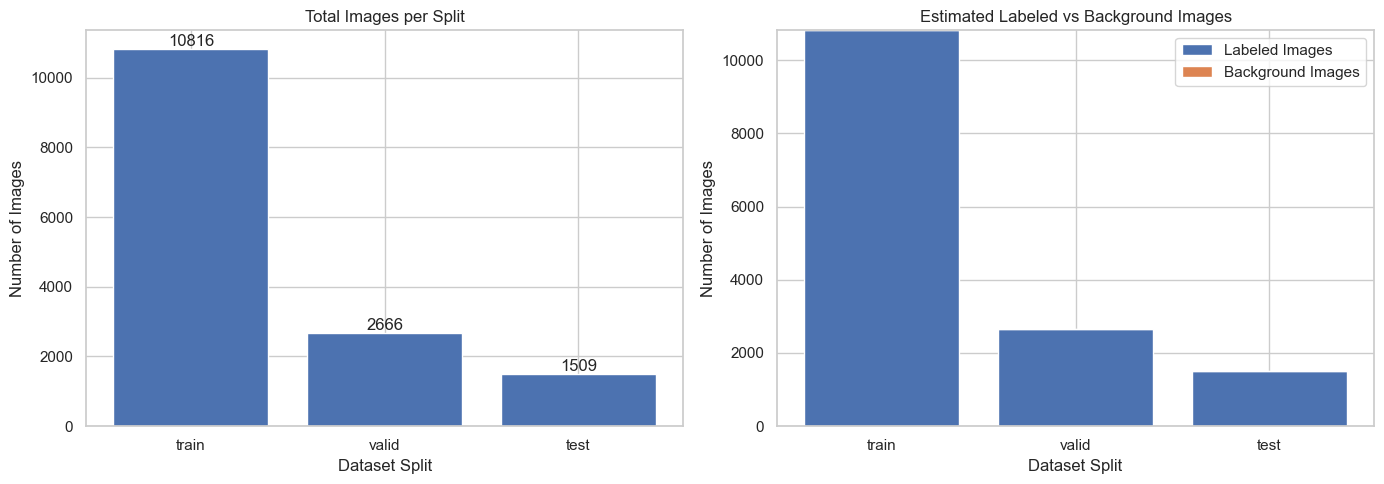

Saved plot at: /content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/plot_dataset_split_fast.png


In [14]:
# Import os for path joins and file existence checks.
import os  # Used to build dataset split paths and verify folders.

# Import glob for fast wildcard file listing.
import glob  # Used to list images and labels without manual loops over directories.

# Import matplotlib for plotting charts.
import matplotlib.pyplot as plt  # Used to create and save bar charts.

# Set dataset root path.
dataset_root = '/content/drive/MyDrive/ShuttleBot/datasets/DataSet_extracted/merged_dataset'  # Main dataset folder containing train/valid/test.

# Define dataset split names used in your folder structure.
splits = ['train', 'valid', 'test']  # Each split should contain images/ and labels/ folders.

# Define valid image extensions for counting image files only.
img_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')  # Allowed image formats.

# Create dictionaries to store stats for each split.
total_images = {}  # Total number of images per split.
total_label_files = {}  # Total number of label txt files per split.
background_images = {}  # Estimated background images (images without label file).
labeled_images = {}  # Estimated labeled images (images with label file).

# Loop through each split and compute fast counts from filenames only.
for split in splits:  # Iterates through train, valid, test.
    # Build image directory path for current split.
    img_dir = os.path.join(dataset_root, split, 'images')  # Example: .../train/images

    # Build label directory path for current split.
    lbl_dir = os.path.join(dataset_root, split, 'labels')  # Example: .../train/labels

    # List all image files in current split.
    img_files = [f for f in glob.glob(os.path.join(img_dir, '*')) if f.lower().endswith(img_exts)]  # Fast file list filter by extension.

    # List all label text files in current split.
    lbl_files = glob.glob(os.path.join(lbl_dir, '*.txt'))  # One label file usually corresponds to one labeled image.

    # Count total images.
    total_images[split] = len(img_files)  # Number of images in split.

    # Count total label files.
    total_label_files[split] = len(lbl_files)  # Number of .txt annotations in split.

    # Estimate labeled images as number of label files (fast approximation).
    labeled_images[split] = min(len(lbl_files), len(img_files))  # Safety min avoids impossible over-count.

    # Estimate background images as images minus labeled images.
    background_images[split] = max(0, len(img_files) - labeled_images[split])  # Safety max avoids negative values.

# Print quick statistics.
print('Total images:', total_images)  # View total split sizes.
print('Label files:', total_label_files)  # View annotation coverage.
print('Estimated labeled images:', labeled_images)  # Approximate labeled count.
print('Estimated background images:', background_images)  # Approximate background count.

# Prepare x-axis category order.
x = splits  # train, valid, test.

# Prepare y-values for first chart.
y_total = [total_images[s] for s in x]  # Total images per split in order.

# Prepare y-values for second chart (stacked).
y_labeled = [labeled_images[s] for s in x]  # Labeled image counts.
y_bg = [background_images[s] for s in x]  # Background image counts.

# Create a figure with two charts side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns for compact comparison.

# Plot total image counts.
axes[0].bar(x, y_total)  # Simple bar chart for split sizes.
axes[0].set_title('Total Images per Split')  # Chart title.
axes[0].set_xlabel('Dataset Split')  # X-axis label.
axes[0].set_ylabel('Number of Images')  # Y-axis label.

# Add value labels above bars.
for i, v in enumerate(y_total):  # Iterate index and value.
    axes[0].text(i, v, str(v), ha='center', va='bottom')  # Show exact number above each bar.

# Plot labeled images as base layer.
axes[1].bar(x, y_labeled, label='Labeled Images')  # Bottom layer in stacked bar.

# Plot background images stacked on top.
axes[1].bar(x, y_bg, bottom=y_labeled, label='Background Images')  # Top layer in stacked bar.

# Set labels/titles for second chart.
axes[1].set_title('Estimated Labeled vs Background Images')  # Describes split composition.
axes[1].set_xlabel('Dataset Split')  # X-axis label.
axes[1].set_ylabel('Number of Images')  # Y-axis label.
axes[1].legend()  # Show color legend.

# Adjust spacing to prevent overlap.
plt.tight_layout()  # Better layout for titles and labels.

# Save plot to Drive.
save_path = '/content/drive/MyDrive/ShuttleBot/runs/shuttle_train_v1/plot_dataset_split_fast.png'  # Output file path.
plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save high-quality figure.

# Show plot in notebook.
plt.show()  # Display figure inline.

# Print saved location.
print('Saved plot at:', save_path)  # Confirmation message.